# Case 2: Klastering Profil Demografi Pemilik

Analisis ini memfokuskan pada latar belakang dari pendiri/pemilik UMKM. Kita ingin melihat apakah ada segmentasi khusus berdasarkan usia, pendidikan, dan gender.

**Fokus Fitur yang Digunakan:**
- Usia Numeric
- Pendidikan Numeric
- Jenis Kelamin Numeric

---
Notebook ini dirancang secara modular dan memanggil fungsi algoritma inti dari `../src/csa_core.py`.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from IPython.display import display
import sys
import os
sys.path.append(os.path.abspath('../src'))

from csa_core import *
np.random.seed(42)

### 1. Load Data Bersih & Persiapan Fitur

In [2]:
df = pd.read_excel('../data/Data_UMKM_Clean.xlsx')

fitur_yang_dipakai = ['Usia Numeric', 'Pendidikan Numeric', 'Jenis Kelamin Numeric']

X_raw = df[fitur_yang_dipakai].values
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Mengeksekusi Case dengan {len(fitur_yang_dipakai)} Dimensi!")
display(df[['Nama Usaha'] + fitur_yang_dipakai].head(5))

Mengeksekusi Case dengan 3 Dimensi!


,Nama Usaha,Usia Numeric,Pendidikan Numeric,Jenis Kelamin Numeric
0,NASYWA SNACK,41,16,1
1,WARUNG ABINAYA,41,6,1
2,TUNGKU MA ENDANG,53,16,1
3,WARUNG BU WIWIK,61,6,1
4,WARUNG PNUNG,64,18,0


### 2. Menghitung Jumlah Klaster Optimal (Elbow Method)

Mengkalkulasi K-Optimal...


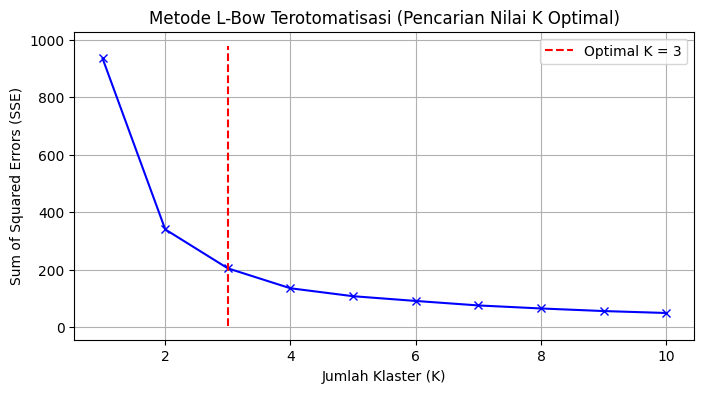

Rekomendasi K-Optimal adalah: 3


In [3]:
print("Mengkalkulasi K-Optimal...")
optimal_k = hitung_optimal_k_elbow(X_scaled, max_k=10)
print(f"Rekomendasi K-Optimal adalah: {optimal_k}")

### 3. Eksekusi KMeans

In [4]:
print(f"Mengeksekusi K-Means Konvensional untuk K={optimal_k}...")
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
final_labels = kmeans.fit_predict(X_scaled)
final_centroids_scaled = kmeans.cluster_centers_


df['Cluster'] = final_labels
df['Cluster'] = df['Cluster'].apply(lambda x: f"C{int(x)+1}")

display(df[['Nama Usaha'] + fitur_yang_dipakai + ['Cluster']].head(10))

Mengeksekusi K-Means Konvensional untuk K=3...


,Nama Usaha,Usia Numeric,Pendidikan Numeric,Jenis Kelamin Numeric,Cluster
0,NASYWA SNACK,41,16,1,C1
1,WARUNG ABINAYA,41,6,1,C3
2,TUNGKU MA ENDANG,53,16,1,C1
3,WARUNG BU WIWIK,61,6,1,C3
4,WARUNG PNUNG,64,18,0,C2
5,KRISNA TRANSPORT,51,0,0,C2
6,LAUNDRY WINA,39,17,1,C1
7,JP CATERING,45,1,1,C3
8,SANDANG TRIAN,41,16,0,C2
9,JUALAN ES KELAPA MUDA,40,16,0,C2


### 4. Evaluasi & Visualisasi

Menggambar Visualisasi Sebaran Klaster...


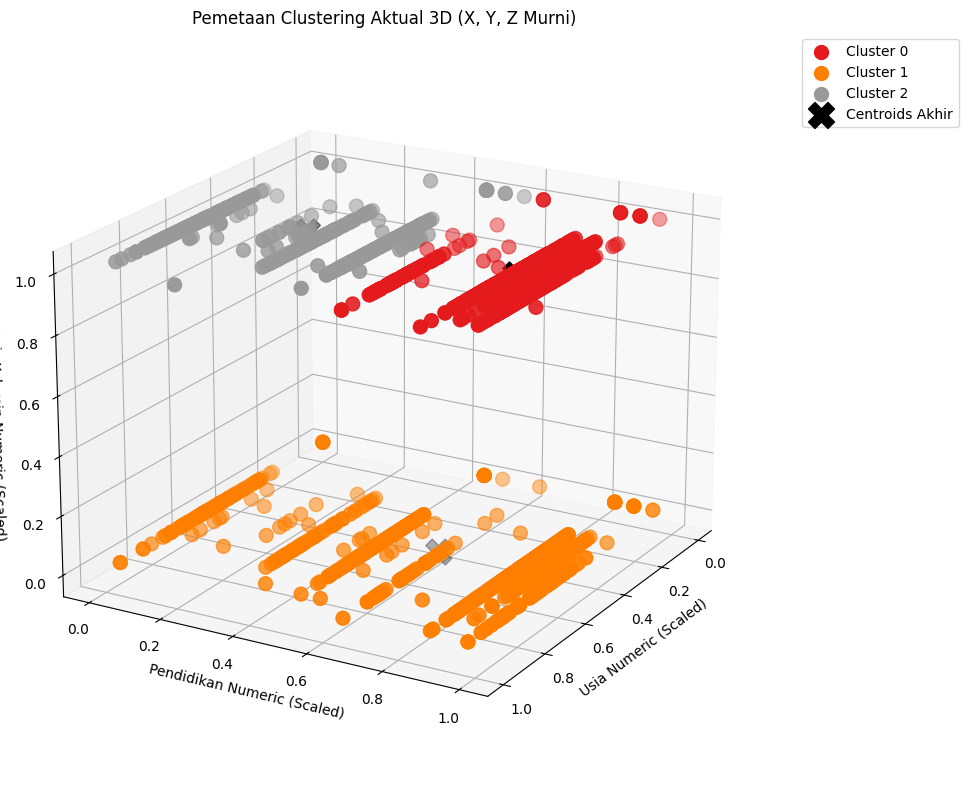


=== EVALUASI METRIK ===
      HASIL UJI METRIK KUALITAS KLASTERISASI
1. Silhouette Score          : 0.5734
   [Interpretasi]: BUKTINYA BAIK. Terdapat struktur klaster yang masuk akal.

2. Davies-Bouldin Index (DBI): 0.6509
   [Interpretasi]: SANGAT BAGUS. Klaster terpisah jauh dengan kepadatan terpusat.

3. Calinski-Harabasz Index   : 4663.2613
   [Interpretasi]: Semakin tinggi angka ini, semakin rapat/padat (dense) klaster Anda.

4. SSE (Sum Squared Error)   : 204.7837
   [Interpretasi]: Mengukur kuadrat jarak deviasi. Turunnya SSE di tiap iterasi membuktikan kinerja baik.

5. MAE (Mean Absolute Error) : 0.2984
   [Interpretasi]: Rata-rata 'jarak lurus' data meleset dari pusat klaster mereka.


In [5]:
print("Menggambar Visualisasi Sebaran Klaster...")
plot_hasil_cluster(X_scaled, final_centroids_scaled, final_labels, fitur_yang_dipakai)

print("\n=== EVALUASI METRIK ===")
evaluasi_kualitas_klasterisasi(X_scaled, final_labels, final_centroids_scaled)

In [6]:
import plotly.express as px

# Membuat Scatter Plot 3D interaktif untuk Case 2
fig_3d = px.scatter_3d(
    df, 
    x=fitur_yang_dipakai[0], # Usia Numeric
    y=fitur_yang_dipakai[1], # Pendidikan Numeric
    z=fitur_yang_dipakai[2], # Jenis Kelamin Numeric
    color='Cluster',
    hover_name='Nama Usaha',
    title="Visualisasi 360° Interaktif: Demografi Pemilik UMKM",
    opacity=0.7,
    size_max=10,
    color_discrete_sequence=px.colors.qualitative.Set2 # Variasi palet warna
)

# Merapikan margin
fig_3d.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig_3d.show()


In [7]:
# Menghitung nilai rata-rata tiap fitur untuk masing-masing klaster
df_avg = df.groupby('Cluster')[fitur_yang_dipakai].mean().reset_index()

# Mengubah bentuk tabel (melt) agar mudah divisualisasikan oleh Plotly
df_melted = df_avg.melt(id_vars='Cluster', value_vars=fitur_yang_dipakai, 
                        var_name='Fitur', value_name='Nilai Rata-rata')

# Membuat Grouped Bar Chart
fig_bar = px.bar(
    df_melted, 
    x='Cluster', 
    y='Nilai Rata-rata', 
    color='Fitur', 
    barmode='group',
    title="Profil Rata-rata Fitur Demografi Pemilik per Klaster",
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig_bar.show()
